In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving TeachingRatings.csv to TeachingRatings.csv


In [ ]:
df = pd.read_csv("TeachingRatings.csv")

In [ ]:
df.head()

,rownames,minority,age,gender,credits,beauty,eval,division,native,tenure,students,allstudents,prof
0,1,yes,36,female,more,0.289916,4.3,upper,yes,yes,24,43,1
1,2,no,59,male,more,-0.737732,4.5,upper,yes,yes,17,20,2
2,3,no,51,male,more,-0.571984,3.7,upper,yes,yes,55,55,3
3,4,no,40,female,more,-0.677963,4.3,upper,yes,yes,40,46,4
4,5,no,31,female,more,1.509794,4.4,upper,yes,yes,42,48,5


**Identifting duplicate cases using prof**

In [ ]:
duplicates = df[df.duplicated(subset='prof', keep=False)]
duplicates = duplicates.sort_values('prof')
duplicates

,rownames,minority,age,gender,credits,beauty,eval,division,native,tenure,students,allstudents,prof
0,1,yes,36,female,more,0.289916,4.3,upper,yes,yes,24,43,1
94,95,yes,36,female,more,0.289916,3.7,upper,yes,yes,86,125,1
95,96,yes,36,female,more,0.289916,3.6,upper,yes,yes,76,125,1
96,97,yes,36,female,more,0.289916,4.4,upper,yes,yes,77,123,1
97,98,no,59,male,more,-0.737732,4.0,upper,yes,yes,35,40,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
455,456,no,32,male,more,1.231394,4.2,lower,yes,yes,111,127,93
93,94,yes,42,female,more,0.420400,3.3,upper,no,yes,48,84,94
461,462,yes,42,female,more,0.420400,3.2,upper,no,yes,54,66,94
460,461,yes,42,female,more,0.420400,3.3,upper,no,yes,52,67,94


**Number of unique instructors**

In [ ]:
print("Number of unique instructors: ", df['prof'].nunique())


Number of unique instructors:  94


**Mean age using all observations**

In [ ]:
mean_age = df['age'].mean()
print("Average age: ", mean_age)

Average age:  48.365010799136066


**Standard deviation using all observations**

In [ ]:
std_age = df['age'].std()
print("Standard deviation: ", std_age)

Standard deviation:  9.802742037864817


**Keeping one obeservation per instructor**

In [ ]:
unique_instructors = df.drop_duplicates(subset='prof')
print(unique_instructors.shape)

(94, 13)


**Mean age after removing duplicates**

In [ ]:
mean_age_unique = unique_instructors['age'].mean()
print("Average age of unique instructors: ", mean_age_unique)

Average age of unique instructors:  47.5531914893617


**Standard deviation after removing duplicates**

In [ ]:
std_age_unique = unique_instructors['age'].std()
print("Standard deviation of unique instructors: ", std_age_unique)

Standard deviation of unique instructors:  10.256513295154951


Mean age of all 463 observations = 48.37 and Standard deviation = 9.80
Mean age of unique instructors = 47.55 and standard deviation = 10.26

In [ ]:
division_eval = df.groupby('division')['eval'].mean()
print(division_eval)

division
lower    4.087261
upper    3.952614
Name: eval, dtype: float64


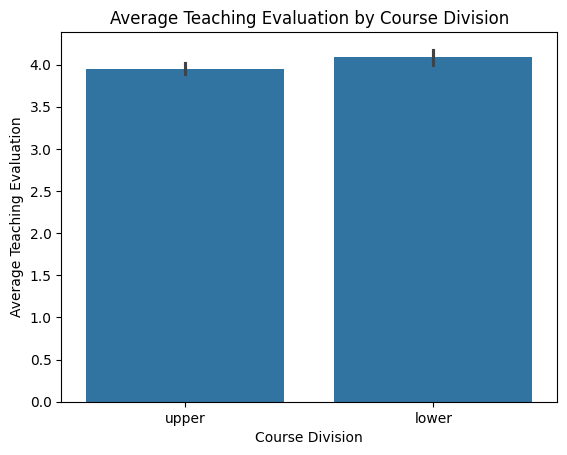

In [ ]:
sns.barplot(
    data = df,
    x = 'division',
    y = 'eval'
)

plt.title('Average Teaching Evaluation by Course Division')
plt.xlabel('Course Division')
plt.ylabel('Average Teaching Evaluation')
plt.show()

Yes, Instructors teaching lower-division courses receive slightly higher average teaching evaluations.

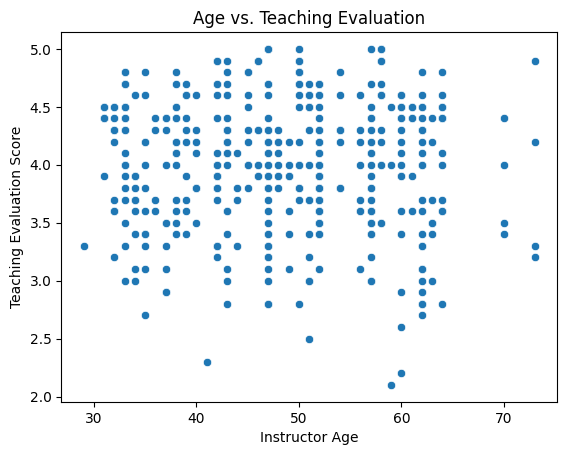

In [ ]:
sns.scatterplot(
    data = df,
    x = 'age',
    y = 'eval'
)

plt.title('Age vs. Teaching Evaluation')
plt.xlabel('Instructor Age')
plt.ylabel('Teaching Evaluation Score')
plt.show()

The scatter plot indicates that there is no strong relationship between instructor age and teaching evaluation scores. Evaluation scores vary considerably across all age groups, suggesting that age alone is not a major factor determining teaching evaluations.

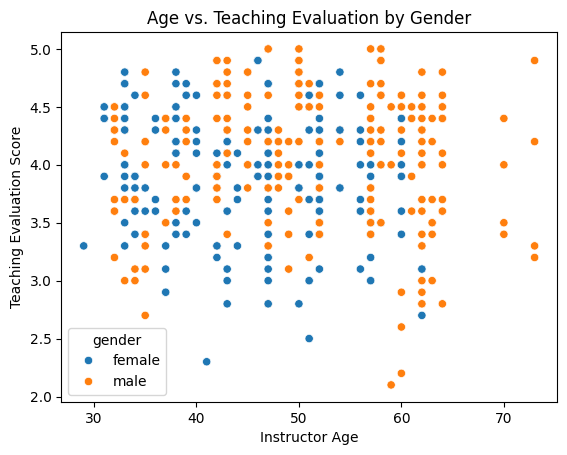

In [ ]:
sns.scatterplot(
    data = df,
    x = 'age',
    y = 'eval',
    hue = 'gender'
)

plt.title('Age vs. Teaching Evaluation by Gender')
plt.xlabel('Instructor Age')
plt.ylabel('Teaching Evaluation Score')
plt.show()

The plot indicates that age does not have a strong relationship with teaching evaluation scores for either male or female instructors. Both genders show considerable variation in evaluation scores across different age groups.

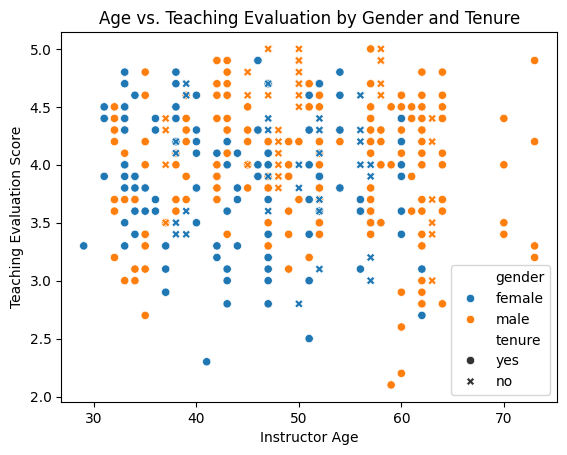

In [ ]:
sns.scatterplot(
    data = df,
    x = 'age',
    y = 'eval',
    hue = 'gender',
    style = 'tenure'
)

plt.title('Age vs. Teaching Evaluation by Gender and Tenure')
plt.xlabel('Instructor Age')
plt.ylabel('Teaching Evaluation Score')
plt.show()

The plot shows that teaching evaluation scores vary considerably across age groups for both genders and tenure statuses. There is no clear relationship between instructor age and evaluation scores, even after considering gender and tenure.